# Sales Forecasting for Retail Decision-Making  
## A Business Intelligence Case Study Using Walmart Sales Data  

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Group Project Portfolio  
**Team Members:** [Daniel Shipton, Samuel Fitzgerald, Nifemi Omoshuli]  
**Dataset Source:** Kaggle – Walmart Sales Dataset  

---

## Executive Summary 

## 1. Problem Definition & Strategic Scoping 

### 1.1 Strategic Scoping 

Walmart is a large-scale retail organisation that operates within a highly competitive and low-margin market where operational efficiency and demand responsiveness is key to lasting profitability. Sales forecasting is a strategic asset that underpins inventory management, workforce allocation, supply chain coordination, promotional planning and financial forecasting.  

An inaccurate financial forecast can cause substantial operational inefficiencies. An overwhelming amount of demands will lead to overstocking, an increased holding cost, markdown losses and waste products. Also, undermining the forecast can lead to stockouts, lost revenue and loss of customer satisfaction. In short, even small forecasting errors can turn into a significant financial impact especially when aggregated across department across department and regions.  

The retail demand is influenced by multiple factors. 

1) Seasonal change (Holiday periods)  

2) Unemployment inflation. 

3) External costs (Fuel prices. The higher the cost of fuel the less amount the customer will spend.)  

4) Local store Intelligence  

A competent business intelligent system will be able to identify the demand drivers and will be able to produce reliable forecast and provide a competitive advantage. 


### 1.2 Business Problem Statement 

This project will address the following problem how can historical weekly sales data across Walmart stores be analysed for firstly the forecast future sales with acceptable predictive accuracy. Secondly, identify the key structure and the economic factors that would influence the sales variability therefor enabling data driven operational planning  

The problem is divided into two different sections.  

1) Predictive dimensions (Generating the forward looking sales forecast)  

2) Diagnostic dimensions (Understand what drives sales variation)  

By combing thee forecasting with explanatory analysis they will move beyond technical modelling and towards actionable business intelligence, aligning directly with the learning outcomes of investigating real-world applications of data mining in business contexts 

## 2. Technical Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Walmart.csv")

weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)
weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))
weekly_total['Lag_4'] = weekly_total['Weekly_Sales'].shift(4)
weekly_total['Lag_12'] = weekly_total['Weekly_Sales'].shift(12)
weekly_total = weekly_total.dropna().reset_index(drop=True)

features = ["Lag_1", "Lag_2", "Rolling_4wk", "Time_Index", "Month"]
X = weekly_total[features]
y = weekly_total["Weekly_Sales"]

split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Setup complete")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

NameError: name 'weekly_total' is not defined

In [4]:
# =========================
# MASTER MODEL CELL — RUN FIRST
# =========================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# -------------------------
# Random Forest
# -------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -------------------------
# Gradient Boosting
# -------------------------
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# -------------------------
# Decision Tree (baseline non-linear)
# -------------------------
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# -------------------------
# MLP Neural Network (scaled X & y)
# -------------------------
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# -------------------------
# SVR (scaled X & y)
# -------------------------
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1000, gamma=0.01))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

print("All models trained successfully.")

NameError: name 'X_train' is not defined

In [5]:
from sklearn.linear_model import LinearRegression, Ridge  

# -------------------------
# Linear Regression
# -------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# -------------------------
# Ridge Regression
# -------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

NameError: name 'X_train' is not defined

In [6]:
# =========================
# MASTER PLOT FUNCTION — RUN ONCE
# =========================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_forecast(y_true, y_pred, model_name):
    plt.figure(figsize=(12,6))

    plt.plot(y_true.values, label="Actual Weekly Sales", linewidth=3)
    plt.plot(y_pred, label=model_name)

    plt.title(f"{model_name} — Actual vs Predicted Weekly Sales")
    plt.xlabel("Forecast Horizon (Weeks)")
    plt.ylabel("Weekly Sales (£ Millions)")

    # Format y-axis to millions
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
    )

    plt.legend()
    plt.show()

In [7]:
# =========================
# MASTER METRICS CELL for metrics comparison table 
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ----- Random Forest -----
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# ----- Gradient Boosting -----
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

# ----- MLP -----
mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp   = r2_score(y_test, y_pred_mlp)

# ----- SVR -----
mae_svr  = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr   = r2_score(y_test, y_pred_svr)


NameError: name 'y_test' is not defined

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 3. Data Quality Assessment

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing.

### 3.1 Data quality check

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [10]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [11]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### 3.2 Summary of Data Quality

The dataset contains 6,435 observations and 8 variables. All columns have complete data with no missing values, indicating high data completeness. The variables are appropriately typed, with numerical features stored as float or integer types, while the Date variable is currently stored as a string and will require conversion to datetime format during preprocessing.

Descriptive statistics show that Weekly_Sales has a wide range, suggesting variability across stores and time periods. External factors such as Temperature, Fuel_Price, CPI, and Unemployment also vary and may influence sales patterns.

Overall, the dataset is clean and suitable for further analysis, with minimal preprocessing required.

## 4. Feature Engineering & Preprocessing

These features enable the identification of seasonal trends and temporal patterns in weekly sales, such as fluctuations across months and peak periods during holidays. Incorporating these variables enhances the effectiveness of both exploratory analysis and predictive modelling by allowing models to account for time-dependent behaviour.

### 4.1 Time-Based Features

The original Date variable had already been processed earlier in the notebook. As a result, key time-based features such as Year, Month, Week, and Day are already present in the dataset.

These features allow for analysis of seasonal trends and patterns in weekly sales, which are essential for both exploratory analysis and predictive modelling.

In [12]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


The dataset now includes additional time-based variables derived from the original date information, confirming that preprocessing has been successfully applied.

## 5. Data Aggregation

To simplify analysis and reduce store-level noise, the dataset is aggregated at a weekly level. This makes overall sales trends easier to observe and provides a more suitable structure for time-series analysis and forecasting.

### 5.1 Weekly Aggregation

In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


### 5.2 Aggregation Rationale

The dataset was aggregated by Date to create a weekly time-series view of total sales across all stores. Weekly_Sales was summed to reflect total revenue for each week, while Temperature, Fuel_Price, CPI, and Unemployment were averaged to provide representative external conditions for the same time period.

Holiday_Flag was aggregated using the maximum value so that any week containing a holiday is correctly identified. This approach simplifies the dataset, reduces store-level noise, and makes overall sales trends easier to analyse and forecast.

## 6. Exploratory Data Analysis (EDA)

#### 6.1 External Variables

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



pairplot_df = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Holiday_Flag"
]]

pairplot_sample = pairplot_df.sample(500, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"],
    hue="Holiday_Flag",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairplot of Sales and Economic Factors (Holiday vs Non-Holiday)", y=1.02)

plt.show()

The pairplot illustrates the relationships between weekly sales and key explanatory variables, including temperature, fuel price, CPI, and unemployment, with holiday periods highlighted. The results show that the relationships between weekly sales and individual predictors are generally weak and non-linear, as indicated by the dispersed distribution of points. This suggests that no single variable strongly determines sales performance, and that sales are influenced by a combination of factors. Holiday periods, highlighted in orange, show slightly higher and more variable sales values, indicating that holidays contribute to increased demand. Additionally, CPI exhibits clustered patterns, reflecting different economic conditions across the dataset. Overall, the pairplot supports the use of more advanced models, such as Random Forest, which can capture complex and non-linear relationships between variables.

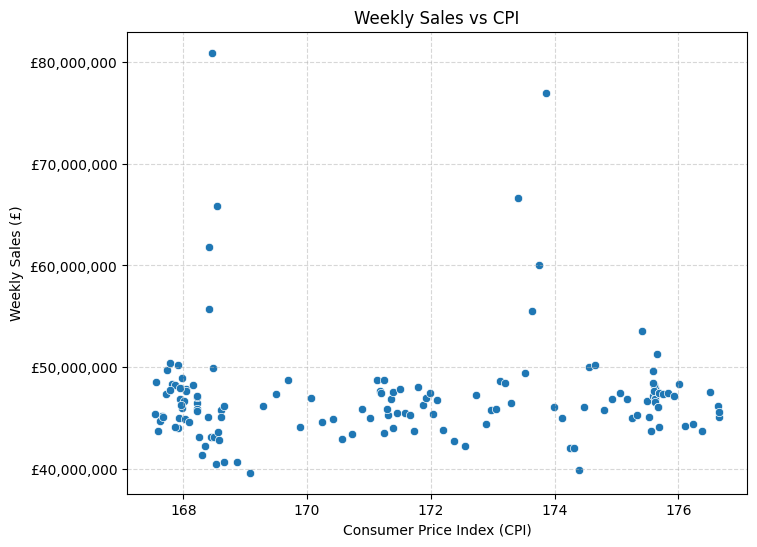

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="CPI", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The scatter plot of Weekly Sales against CPI suggests that the relationship between the two variables is weak and non-linear. Sales values are distributed across multiple CPI levels, with visible clustering patterns that may reflect different economic periods within the dataset. This indicates that CPI may have some influence on sales, but it is unlikely to act as a strong standalone predictor. Instead, its effect is likely to interact with other variables in the forecasting model.

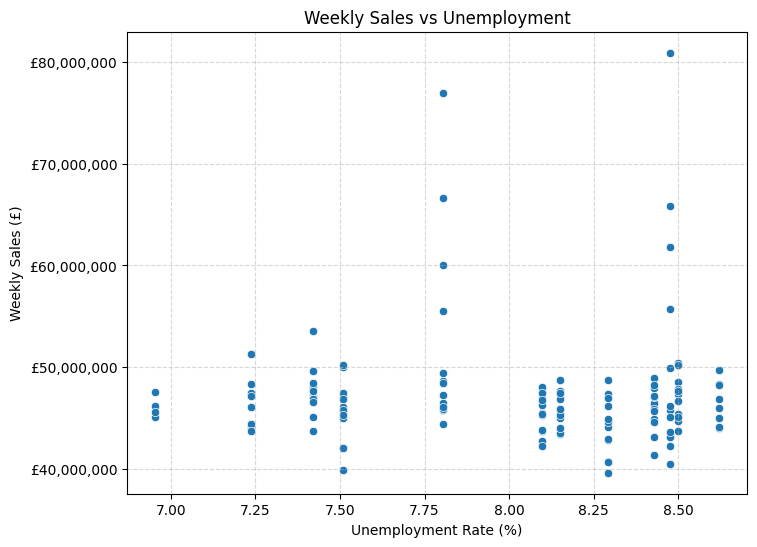

In [15]:
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Unemployment", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The relationship between weekly sales and unemployment appears weak, with a slight negative trend indicating that higher unemployment levels may be associated with reduced sales. However, the scattered distribution suggests that unemployment is not a strong standalone predictor and likely interacts with other variables in influencing sales performance.

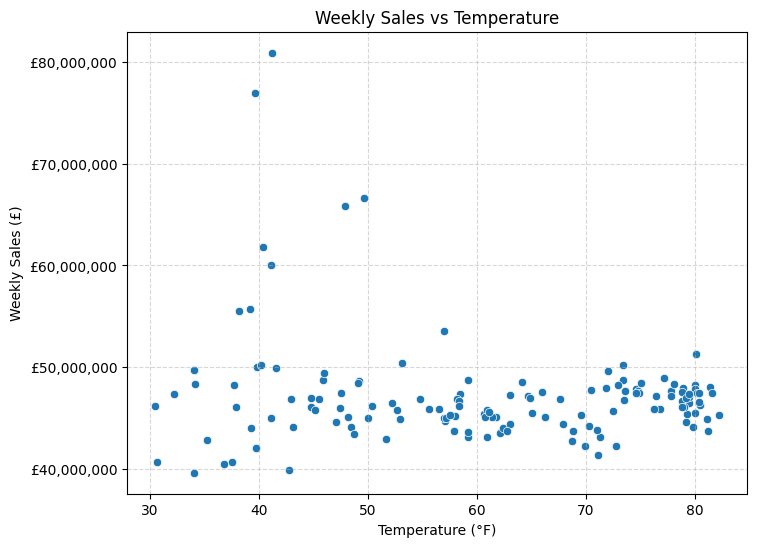

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))
sns.scatterplot(data=weekly_total, x="Temperature", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature (°F)")  # or °C depending on dataset
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The scatter plot between weekly sales and temperature shows no clear relationship, with sales values widely dispersed across all temperature ranges. This indicates that temperature does not have a significant direct impact on sales and is unlikely to be a strong predictor in the forecasting model.

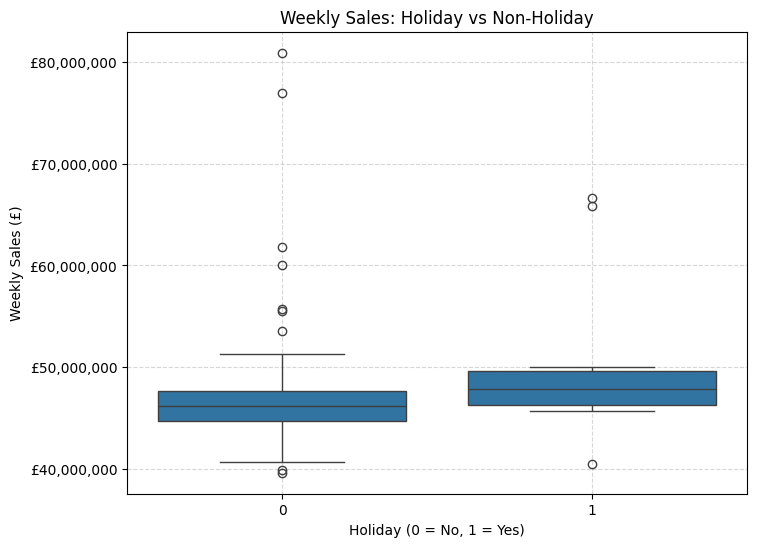

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))

sns.boxplot(data=weekly_total, x="Holiday_Flag", y="Weekly_Sales")

# Format Y-axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Weekly Sales (£)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The boxplot shows that weekly sales during holiday periods tend to have a slightly higher median and greater variability compared to non-holiday weeks. 

However, there is significant overlap between the distributions, indicating that while holidays contribute to increased demand, they are not the sole driver of high sales periods. Other factors, such as seasonal trends and time-based effects, also play an important role.

This suggests that the Holiday_Flag variable is useful but should be considered alongside additional features in the forecasting model.

#### 6.2 Sales Trend over time 

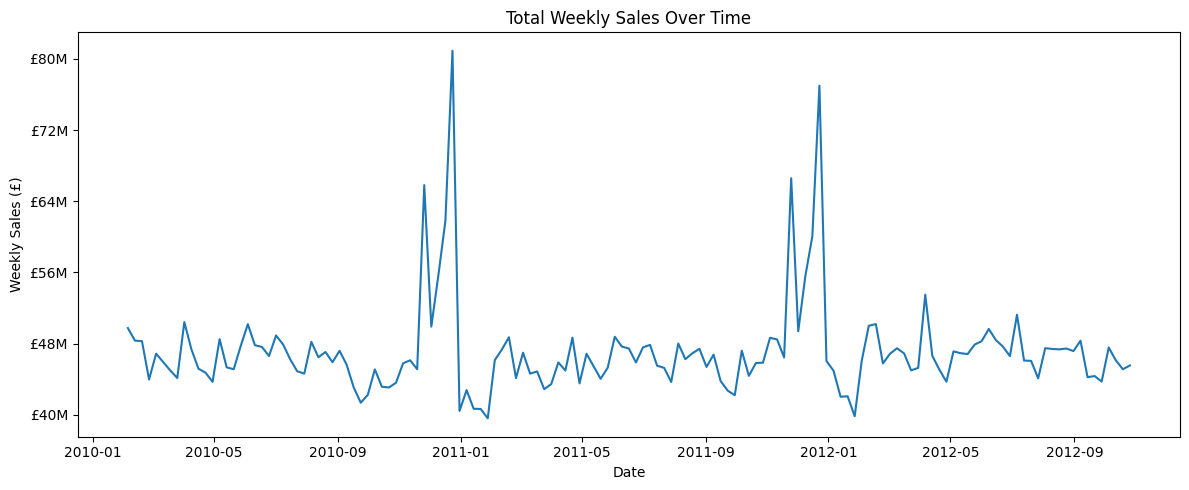

In [18]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (£)")

ax = plt.gca()

# Format to £ millions
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)

# OPTIONAL: cleaner tick spacing (THIS is the bit you asked about)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The time series plot shows that weekly sales fluctuate over time with noticeable peaks, particularly towards the end of each year. These spikes suggest that sales are strongly influenced by recurring seasonal demand patterns.

Sales tend to increase significantly between October and December, followed by a sharp decline in January. This reflects typical retail behaviour during holiday periods and post-holiday slowdowns.

#### 6.3 Rolling Average Trend

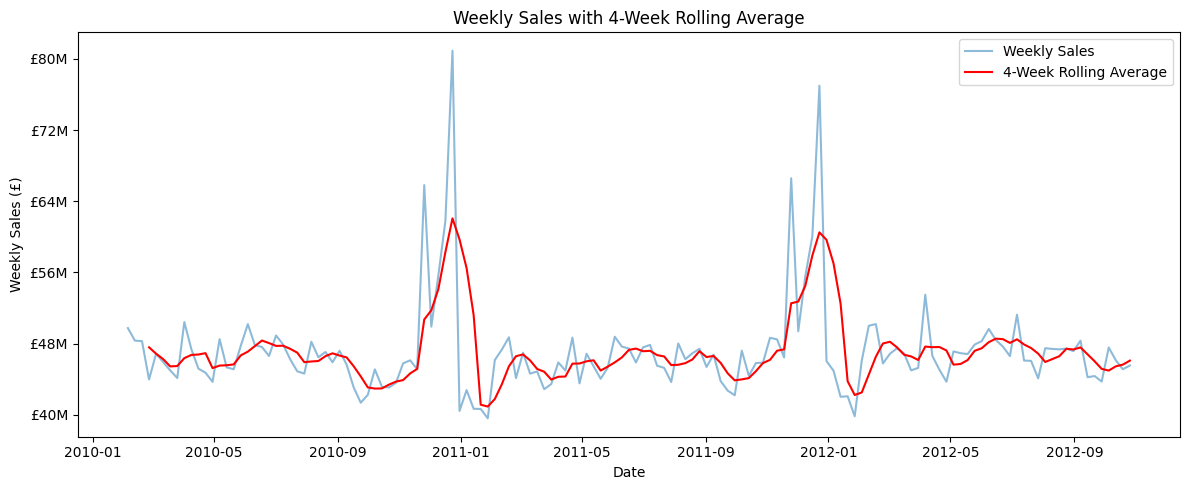

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()

plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')

plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (£)")

plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The 4-week rolling average smooths short-term fluctuations and highlights the underlying trend in weekly sales. It confirms that the series is generally stable over time but exhibits clear seasonal peaks toward the end of each year, followed by a sharp decline in January.

#### 6.4 Monthly seasonality

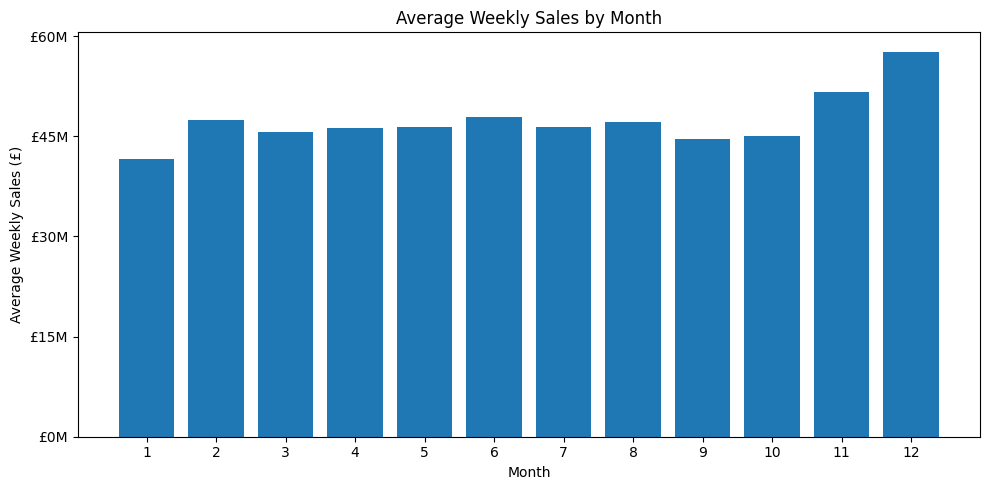

In [20]:
import matplotlib.ticker as ticker

# Create Month column from Date
weekly_total['Month'] = weekly_total['Date'].dt.month

# Calculate average weekly sales by month
monthly_avg = (
    weekly_total
    .groupby('Month', as_index=False)['Weekly_Sales']
    .mean()
)

# Plot monthly seasonality
plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales (£)")
plt.xticks(range(1,13))

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}M')
)
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

plt.tight_layout()
plt.show()

The monthly aggregation highlights clear seasonal patterns in weekly sales. Sales peak in December, likely due to holiday demand, followed by a noticeable decline in January.

This consistent seasonal trend supports the inclusion of the Month variable as an important predictor in the forecasting model.

#### 6.5 Correlation Matrix 

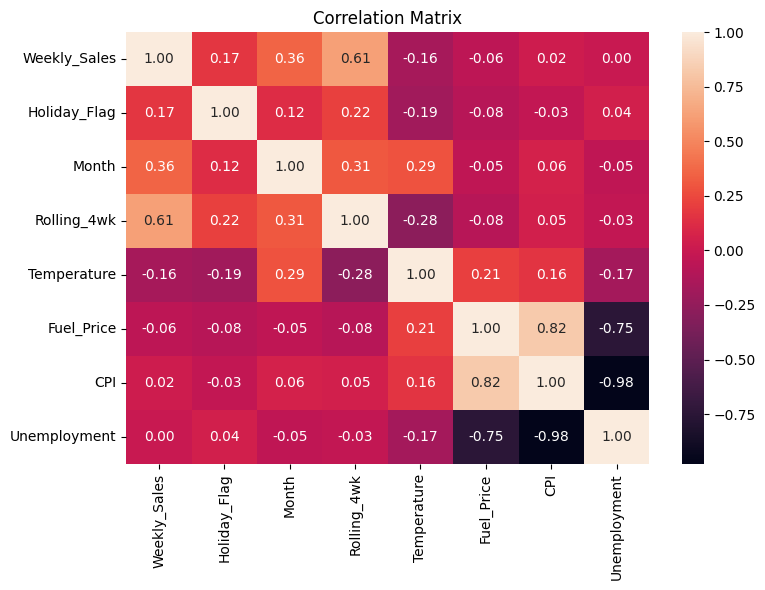

In [21]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix shows that the 4-week rolling average has the strongest relationship with weekly sales (0.61), indicating that recent sales trends are highly predictive.

The Month variable also shows a moderate positive correlation (0.37), supporting the presence of seasonal patterns observed earlier.

In contrast, economic variables such as CPI, Fuel Price, and Unemployment exhibit weak correlations with sales, suggesting that they are not strong standalone predictors.

Overall, this analysis indicates that sales are influenced by a combination of temporal patterns rather than individual external factors, supporting the use of more advanced models such as Random Forest.

## Conclusion


The exploratory data analysis reveals that weekly sales are highly variable and are not strongly driven by any single factor. Holiday periods are associated with higher and more volatile sales, indicating increased demand during these times. Economic variables such as CPI and unemployment show weak and non-linear relationships with sales, while temperature demonstrates little to no direct influence. The presence of clustering and dispersed patterns across the visualisations suggests that the relationships between variables are complex and not purely linear. These findings indicate that traditional linear models may struggle to capture the underlying patterns in the data. Therefore, more flexible machine learning approaches, such as Random Forest, are appropriate for modelling and forecasting weekly sales.

# 7. Linearity vs Non-Linearity Analysis

non linear baseline model 

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,        # prevents overfitting
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

NameError: name 'X_train' is not defined

In [23]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

NameError: name 'y_test' is not defined

In [24]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_dt, label="Decision Tree")
plt.legend()
plt.title("Decision Tree — Actual vs Predicted Weekly Sales")
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

The Decision Tree regressor was used as a baseline non-linear model because it can capture complex relationships through threshold-based splits without assuming a linear form. As shown in the figure, the model produces step-like, piecewise-constant predictions, reflecting how observations within the same region receive identical values. While the tree captures overall sales levels, it does not reproduce short-term fluctuations or extreme values due to its discrete structure. Nevertheless, it provides an interpretable reference point for evaluating more advanced non-linear models such as Random Forest and Gradient Boosting.

non linear models advanced 

Random Forest model 

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

NameError: name 'X_train' is not defined

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_rf, label="Random Forest")

# Titles and labels
plt.title("Random Forest — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to millions (removes 1e7)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

The Random Forest regressor was selected as a non-linear ensemble method capable of modelling complex relationships between input variables and weekly sales. Unlike linear models, Random Forest does not assume a linear relationship and can capture interactions, threshold effects, and non-monotonic patterns commonly observed in retail demand data.

As shown in the figure, the Random Forest predictions broadly follow the overall trend of the actual weekly sales, indicating that the model successfully captures medium-term variations in demand. The model responds to directional changes and reproduces general fluctuations across the time horizon, demonstrating its ability to learn underlying patterns from the training data.

However, the predicted series appears noticeably smoother than the actual observations. Extreme peaks and troughs — particularly the large spike around period 10 and sharp declines later in the series — are not fully reproduced. This behaviour is characteristic of ensemble tree methods, which average predictions across many decision trees, reducing variance but also dampening short-term volatility. While this smoothing improves stability and robustness to noise, it can limit responsiveness to sudden demand shocks such as promotional events, holidays, or external disruptions.

From a forecasting perspective, the model provides reliable baseline predictions and is well-suited to strategic planning scenarios where stable demand estimates are preferred over highly reactive forecasts. However, for operational decision-making requiring precise anticipation of sharp fluctuations, additional models or feature engineering may be necessary.
Overall, the Random Forest model demonstrates strong capability in modelling non-linear relationships and capturing the general structure of weekly sales, but its tendency to smooth extreme variations highlights a trade-off between stability and sensitivity to short-term changes.


GBM Graident Booster 

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

NameError: name 'X_train' is not defined

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_gbr, label="Gradient Boosting")

# Titles and labels
plt.title("Gradient Boosting — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes 1e7 notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

Gradient Boosting regressor is selected due to its ability to capture complex relationships in retail demand data through sequential error correction. Unlike bagging methods such as random forrest, Gradient boosting regressor builds trees iteratively with each new tree trained to  minimise the residual errors of the previous ensemble.This means the model can detect subtle patterns local trends and non linear interactions between predictors that are not well represented by linear approaches 

As illustrated in the figure, the Gradient Boosting predictions closely follow the overall trajectory of the actual weekly sales series. The model successfully captures medium-term fluctuations and directional changes, particularly around periods of rising demand and subsequent declines. Compared with simpler models, the predicted series demonstrates responsiveness to shifts in the underlying pattern rather than producing a constant or purely smoothed estimate.

One problem with gradient boosting in this case the predictions remain smoother than the observed data and extreme peaks are not fully reproduced an example of this is the pronounced spike around period 10 and sharp drop shortly after only partially captured this behavour is expected gradient boosting balances biast and variance by avoiding overfitting to noise or isolated events  In retail forecasting contexts, such smoothing can be advantageous because it produces stable predictions that are less sensitive to irregular shocks such as short-term promotions or anomalies.

Overall, the model achieves a strong compromise between flexibility and stability. It is sufficiently expressive to model non-linear demand dynamics while maintaining robust generalisation across the time horizon. This makes Gradient Boosting particularly suitable for strategic forecasting tasks where reliable trend estimation is more valuable than exact replication of extreme fluctuations.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("GBR MAE:", mae_gbr)
print("GBR RMSE:", rmse_gbr)

NameError: name 'y_test' is not defined

Support Vector Regression 

In [30]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1000,        # MUCH stronger
        gamma=0.01,    # Controls flexibility
        epsilon=0.1
    ))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

NameError: name 'X_train' is not defined

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_svr, label="SVR (RBF Kernel)")

# Titles and labels
plt.title("Support Vector Regression — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

The SVR model produces uneven predictions that often move away from the real sales values. It occasionally aligns with the extreme values it often predicts values that are way to high or too low. This inconsistent behavior shows the model does not learn the underlying pattern well as it is very sensitive to how its settings are configured. As a result, it can't be a reliable choice for the Walmart forecasting task 


In [32]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

NameError: name 'y_test' is not defined

MLP Regressor 

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    transformer=StandardScaler()
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

NameError: name 'X_train' is not defined

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

# Actual vs Prediction
plt.plot(y_test.values, label="Actual Weekly Sales", linewidth=3)
plt.plot(y_pred_mlp, label="MLP Neural Network")

# Titles and labels
plt.title("MLP Regressor — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions (removes scientific notation)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Neural Network Results")
print(f"MAE: £{mae_mlp/1e6:.2f}M")
print(f"RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"R²: {r2_mlp:.3f}")

NameError: name 'y_test' is not defined

Model Comparison graph 

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))

# =========================
# MOST PROMINENT — Actual
# =========================
plt.plot(
    y_test.values,
    label="Actual Weekly Sales",
    linewidth=4,
    color="black"
)

# =========================
# SECOND — BEST MODEL (RF)
# =========================
plt.plot(
    y_pred_rf,
    label="Random Forest (Best)",
    linewidth=3,
    color="orange"
)

# =========================
# LESS PROMINENT MODELS
# =========================
plt.plot(y_pred_gbr, label="Gradient Boosting", alpha=0.5, linestyle="--")
plt.plot(y_pred_mlp, label="MLP Neural Network", alpha=0.5, linestyle="--")
plt.plot(y_pred_svr, label="SVR", alpha=0.5, linestyle="--")

# Titles and labels
plt.title("Comparison of Non-Linear Models — Actual vs Predicted Weekly Sales")
plt.xlabel("Forecast Horizon (Weeks)")
plt.ylabel("Weekly Sales (£ Millions)")

# Format y-axis to £ millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x/1e6:.1f}M')
)

plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1400x700 with 0 Axes>

Four non-linear models were evaluated for forecasting weekly sales: Random Forest, Gradient Boosting, a Multi-Layer Perceptron (MLP) neural network, and Support Vector Regression (SVR). Each model exhibits distinct predictive behaviour reflecting its underlying learning mechanism.

The Random Forest model captures the general trend of the data and produces stable predictions across the time horizon. Its ensemble averaging reduces variance and prevents extreme errors, but this also leads to noticeable smoothing. Consequently, sharp peaks and troughs in the actual sales series are underrepresented, indicating limited responsiveness to sudden demand fluctuations.

The Gradient Boosting model demonstrates a closer fit to the direction of short-term changes than Random Forest. Because boosting sequentially corrects residual errors, it is more sensitive to local variations in the data. However, the model still produces conservative predictions and struggles to fully reproduce extreme values, suggesting some degree of bias toward the central tendency.

The MLP neural network produces predictions that follow the overall structure of the series while showing greater flexibility than the tree-based models. The neural network responds to several directional shifts and captures some intermediate fluctuations, indicating its ability to model complex non-linear relationships. Nevertheless, the predictions remain smoother than the observed data, and certain abrupt changes are not fully captured.

In contrast, the SVR model exhibits large oscillations and frequently deviates from the actual series. Although it occasionally aligns with peaks, it also produces substantial overestimation and underestimation across multiple periods. This behaviour suggests instability and reduced generalisation performance for this dataset, likely due to sensitivity to hyperparameters and noise.

Overall, ensemble methods (Random Forest and Gradient Boosting) provide the most stable and reliable forecasts, while SVR demonstrates the weakest performance due to erratic predictions.

The Gradient Boosting model provides the most balanced performance across the evaluation period. It closely follows the direction of the actual sales series, captures medium-term fluctuations, and avoids the excessive smoothing of Random Forest as well as the instability observed in SVR. While it does not perfectly reproduce extreme peaks, it maintains consistent proximity to the observed values without producing unrealistic deviations.

From a forecasting perspective, this balance between responsiveness and stability is desirable. The model is sufficiently sensitive to changing demand patterns while remaining robust to noise, making it well suited for practical retail planning applications.

Metric comparison table 

In [37]:
print("Non-Linear Model Performance (Error in £ Millions)\n")

print(f"Random Forest      — MAE: £{mae_rf/1e6:.2f}M   RMSE: £{rmse_rf/1e6:.2f}M")
print(f"Gradient Boosting  — MAE: £{mae_gbr/1e6:.2f}M   RMSE: £{rmse_gbr/1e6:.2f}M")
print(f"MLP Neural Network — MAE: £{mae_mlp/1e6:.2f}M   RMSE: £{rmse_mlp/1e6:.2f}M")
print(f"SVR (RBF Kernel)   — MAE: £{mae_svr/1e6:.2f}M   RMSE: £{rmse_svr/1e6:.2f}M")

Non-Linear Model Performance (Error in £ Millions)



NameError: name 'mae_rf' is not defined

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

NameError: name 'y_test' is not defined

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Model names
models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# MAE values converted to £ millions
mae_scores_millions = [
    mae_rf / 1e6,
    mae_gbr / 1e6,
    mae_mlp / 1e6,
    mae_svr / 1e6
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, mae_scores_millions)

# Highlight best (lowest MAE)
best_index = mae_scores_millions.index(min(mae_scores_millions))
bars[best_index].set_color("green")

plt.title("MAE Comparison of Non-Linear Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (£ Millions)")

# Format axis with £
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

NameError: name 'mae_rf' is not defined

RMSE Comparison Graph 

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models = ["Random Forest", "Gradient Boosting", "MLP", "SVR"]

# Convert RMSE to £ millions
rmse_scores_millions = [
    rmse_rf / 1e6,
    rmse_gbr / 1e6,
    rmse_mlp / 1e6,
    rmse_svr / 1e6
]

plt.figure(figsize=(10,6))
plt.bar(models, rmse_scores_millions)

plt.title("RMSE Comparison of Non-Linear Models")
plt.ylabel("Root Mean Squared Error (£ Millions)")
plt.xlabel("Model")

# Format y-axis with £ symbol
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'£{x:.1f}M')
)

plt.show()

NameError: name 'rmse_rf' is not defined

## 8. Model Development

In [41]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [42]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

In [43]:
df = df.drop("Date", axis=1)

In [44]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
y_pred_rf = rf_model.predict(X_test)

In [48]:
# Calculate residuals (prediction errors)
residuals_rf = y_test - y_pred_rf

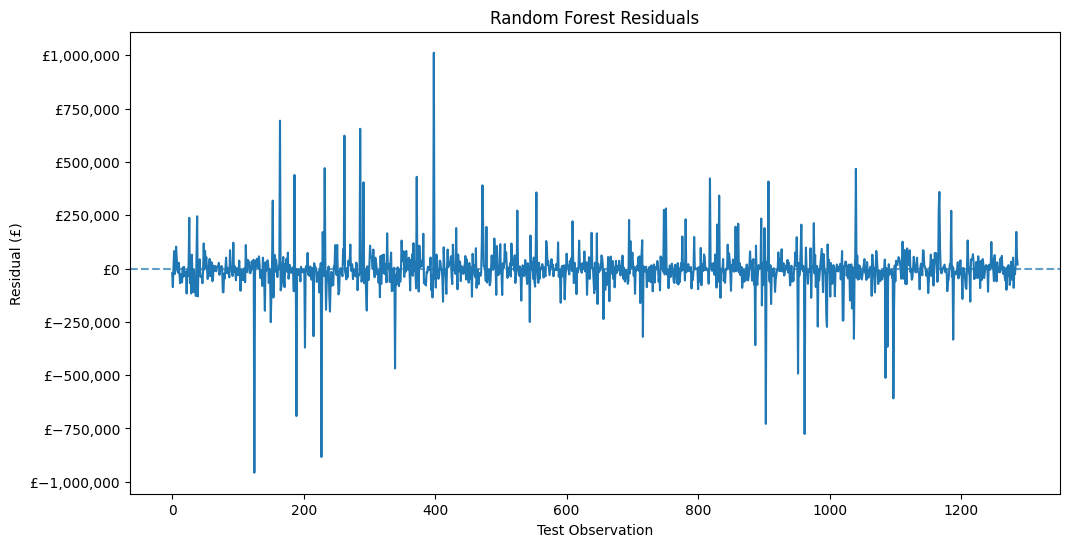

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))
plt.plot(residuals_rf.values)
plt.axhline(0, linestyle="--", alpha=0.7)

formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Random Forest Residuals")
plt.xlabel("Test Observation")
plt.ylabel("Residual (£)")

plt.show()

The residual plot illustrates the prediction errors of the Random Forest model, calculated as the difference between actual and predicted weekly sales. Ideally, residuals should be randomly distributed around zero, indicating that the model does not consistently overestimate or underestimate values. In this case, most residuals are clustered near the zero line, suggesting that the model generally produces accurate predictions for typical sales levels. The lack of a visible trend or pattern indicates that the model does not suffer from systematic bias. However, several large positive and negative spikes are present, representing weeks where prediction errors are significantly higher. These deviations likely correspond to unusual demand patterns or external factors not fully captured by the model. Overall, the residual distribution indicates that the model performs reliably for normal sales behaviour but is less accurate during periods of extreme variation.

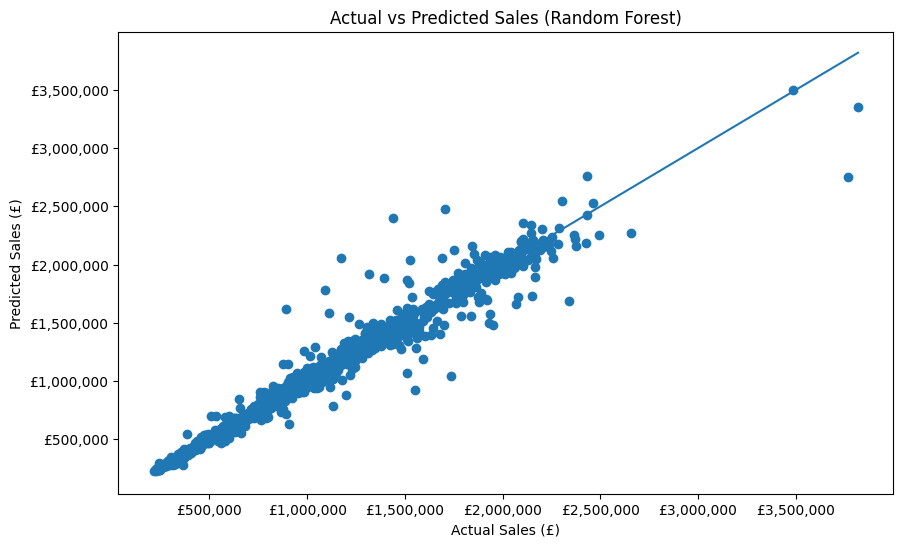

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf)

# Diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

# Format axis as currency (£)
formatter = mtick.StrMethodFormatter('£{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales (£)")
plt.ylabel("Predicted Sales (£)")

plt.show()

Actual vs Predicted Sales Analysis

The Actual vs Predicted plot illustrates the relationship between the observed weekly sales and the values predicted by the Random Forest model. The majority of data points are closely aligned along the diagonal reference line, indicating a strong agreement between predicted and actual values. This suggests that the model is effective in capturing the overall sales patterns within the dataset.

However, some dispersion is visible, particularly at higher sales values, where predictions deviate further from the actual values. This indicates that the model is less accurate when forecasting extreme sales levels, likely due to the increased variability during peak demand periods such as holidays or promotional events.

Overall, the plot demonstrates that the Random Forest model provides a good level of predictive accuracy, with most errors being relatively small, while highlighting some limitations in handling high-value outliers.

## 9. Conclusion